# Per-cluster resolution policies — k-fold evaluation

Does routing each question to its own image resolution beat simply running every
question at one well-chosen fixed resolution?

**The bar is `lift`**: accuracy minus that of a *fixed* budget costing the same.
Beating "always full resolution" while spending less is not evidence — a cheaper
fixed budget usually does that too. Every number below is measured on documents
the clustering never saw: KMeans and the per-cluster budgets are fit on the
training folds and applied to the held-out fold.

Two benchmarks are evaluated side by side, using the sweeps under `benchmarks/`.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError("could not locate the project root")
    PROJECT_ROOT = PROJECT_ROOT.parent

# ── Sweeps to evaluate: label -> results directory ────────────────────────────
RUNS = {
    "seedbench_2_plus": PROJECT_ROOT / "benchmarks/seedbench_2_plus/Qwen-Qwen3.5-4B",
    "mmmu_pro_standard": PROJECT_ROOT / "benchmarks/mmmu_pro_standard/Qwen-Qwen3.5-4B-tok32k",
}

# ── Cross-validation ──────────────────────────────────────────────────────────
K_VALUES = [2, 3, 5, 8, 12, 20, 30, 50]
N_FOLDS = 5
RANDOM_STATE = 42

# K used for the heatmap and the strategy comparison chart; must be in K_VALUES.
SUMMARY_K = 30

# Fold whose training rows the heatmap shows. Same split as the evaluation.
HEATMAP_FOLD = 0

# ── Cost basis. sent_px is what the pipeline controls, and the basis the paper
#    reports: cost is stated relative to the *native* image, so 100% is the
#    budget ladder's top rung only where that rung actually reaches native.
#    seedbench images are uniformly 800x800, so its 100% is 640,000 px — the
#    800,000 budget sends no more than the 640,000 one. input_tokens is the
#    alternative basis (what the model bills); both are per document per budget.
COST = "sent_px"

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
RESULTS_DIR = PROJECT_ROOT / "src/clustering/results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer

from clustering.data import load_sweep, question_text
from clustering.kfold import cross_validate, fixed_frontier, lift

sns.set_style("whitegrid")
%matplotlib inline

encoder = SentenceTransformer(EMBEDDING_MODEL)

sweeps, embeddings = {}, {}
for label, run_dir in RUNS.items():
    sweep = load_sweep(run_dir, cost=COST)
    sweeps[label] = sweep
    embeddings[label] = encoder.encode(
        question_text(sweep.task, sweep.doc_ids), show_progress_bar=False, convert_to_numpy=True
    )
    print(f"{label}: {sweep.n_documents} documents x {len(sweep.budgets)} budgets")

/home/das/poli/redes-neurais-e-dl/scale-wise-optimizer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3876.89it/s]

seedbench_2_plus: 2277 documents x 10 budgets


mmmu_pro_standard: 1730 documents x 10 budgets


In [3]:
# Shared styling: colours, markers, display names and legend order
# (Fixed budget, BPC, E99, E95) stay identical across every chart.
STYLE = {
    "best": ("*", "#2ecc71", 280),
    "efficient_99": ("s", "#e74c3c", 180),
    "efficient_95": ("D", "#e67e22", 180),
}
NAMES = {"best": "BPC", "efficient_99": "E99", "efficient_95": "E95"}
COST_LABEL = {"sent_px": "pixels sent", "input_tokens": "input tokens"}[COST]


# Short name for a fixed rung, capped at what the budget can actually reach.
# Budgets are nominal: the pipeline never upscales, so a budget above every
# native image is a no-op and naming the rung after it overstates the cost.
# seedbench's images are uniformly 800x800, so its 800,000 rung is really
# 640,000 — which is also the 100% this benchmark's cost axis divides by.
def rung(label, budget):
    pixels = sweeps[label].effective_budget(budget)
    return f"{pixels / 1_000:g}k" if pixels < 1_000_000 else f"{pixels / 1_000_000:g}M"


# The denominator every cost percentage is divided by, printed so a figure
# caption can name it rather than imply the nominal top budget.
for label in RUNS:
    full = sweeps[label].costs.mean(axis=0).max()
    top = sweeps[label].budgets.max()
    print(f"{label}: 100% = {full:,.0f} {COST_LABEL} per document "
          f"(the {top:,} budget, which reaches {rung(label, top)} pixels)")

seedbench_2_plus: 100% = 640,000 pixels sent per document (the 800,000 budget, which reaches 640k pixels)
mmmu_pro_standard: 100% = 356,453 pixels sent per document (the 800,000 budget, which reaches 800k pixels)


---
## 1. The fixed-budget frontier

This is what routing has to beat. Each point is one budget applied to every
document, averaged over the held-out folds.

In [4]:
folds = {label: cross_validate(sweeps[label], embeddings[label], K_VALUES, N_FOLDS, RANDOM_STATE)
         for label in RUNS}

for label in RUNS:
    curve = fixed_frontier(folds[label])
    curve.insert(0, "benchmark", label)
    print(curve.to_string(index=False))
    print()

       benchmark   budget     cost  accuracy
seedbench_2_plus   2000.0   1936.0  0.470365
seedbench_2_plus  12500.0  12321.0  0.475193
seedbench_2_plus  25000.0  24964.0  0.492305
seedbench_2_plus  50000.0  49729.0  0.527881
seedbench_2_plus 100000.0  99856.0  0.595079
seedbench_2_plus 150000.0 149769.0  0.634166
seedbench_2_plus 250000.0 250000.0  0.679407
seedbench_2_plus 400000.0 399424.0  0.693457
seedbench_2_plus 600000.0 599076.0  0.706188
seedbench_2_plus 800000.0 640000.0  0.712347

        benchmark   budget          cost  accuracy
mmmu_pro_standard   2000.0   2269.647977  0.258960
mmmu_pro_standard  12500.0  14354.527746  0.324855
mmmu_pro_standard  25000.0  28342.460694  0.363584
mmmu_pro_standard  50000.0  54996.954913  0.408671
mmmu_pro_standard 100000.0 101960.045087  0.432948
mmmu_pro_standard 150000.0 140415.798266  0.445665
mmmu_pro_standard 250000.0 198580.300578  0.431792
mmmu_pro_standard 400000.0 260851.878613  0.437572
mmmu_pro_standard 600000.0 318293.048555  0.4

---
## 2. Lift — the result that matters

`lift > 0` means routing beat a fixed budget of the same cost. `NaN` marks
policies cheaper than the cheapest fixed budget, where no comparison exists
rather than an extrapolated one.

In [5]:
lifts = {}
for label in RUNS:
    table = lift(folds[label])
    table.insert(0, "benchmark", label)
    lifts[label] = table
    best = table.dropna(subset=["lift"]).sort_values("lift", ascending=False)
    print(f"── {label} ── best lift by strategy")
    print(best.groupby("strategy").head(1)[
        ["strategy", "k", "accuracy", "fixed_at_same_cost", "lift", "cost_share"]
    ].round(4).to_string(index=False))
    print(f"   positive lift in {(table['lift'] > 0).sum()} of {table['lift'].notna().sum()} comparable settings")
    print()

all_lift = pd.concat(lifts.values(), ignore_index=True)
all_lift.to_csv(RESULTS_DIR / "kfold_lift.csv", index=False)
pd.concat(folds.values(), keys=folds, names=["benchmark", None]).reset_index(level=0).to_csv(
    RESULTS_DIR / "kfold_folds.csv", index=False
)

── seedbench_2_plus ── best lift by strategy
    strategy    k  accuracy  fixed_at_same_cost    lift  cost_share
efficient_95  3.0    0.6842              0.6857 -0.0015      0.4953
        best  2.0    0.7075              0.7114 -0.0039      0.9906
efficient_99 20.0    0.6956              0.7013 -0.0056      0.8151
   positive lift in 0 of 24 comparable settings

── mmmu_pro_standard ── best lift by strategy
    strategy   k  accuracy  fixed_at_same_cost    lift  cost_share
        best 5.0    0.4422              0.4399  0.0023      0.4623
efficient_99 5.0    0.4405              0.4418 -0.0014      0.4390
efficient_95 5.0    0.4277              0.4344 -0.0066      0.2980
   positive lift in 1 of 24 comparable settings



---
## 3. Lift against K

If routing worked, lift would be reliably positive across K rather than
flickering around zero.

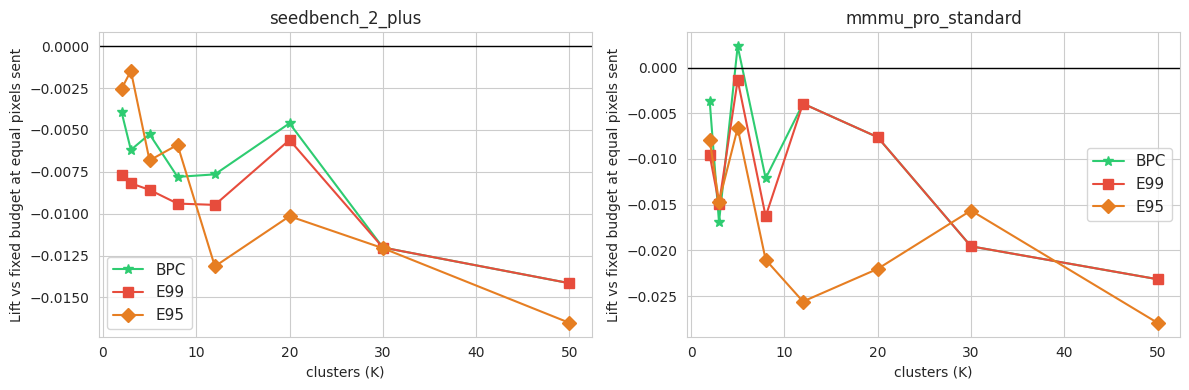

In [6]:
fig, axes = plt.subplots(1, len(RUNS), figsize=(6 * len(RUNS), 4), squeeze=False)
for ax, label in zip(axes[0], RUNS, strict=True):
    table = lifts[label]
    for name, (marker, colour, _) in STYLE.items():
        group = table[table["strategy"] == name]
        ax.plot(group["k"], group["lift"], marker=marker, ms=7, color=colour, label=NAMES[name])
    ax.axhline(0, color="black", lw=1)
    ax.set_title(label)
    ax.set_xlabel("clusters (K)")
    ax.set_ylabel(f"Lift vs fixed budget at equal {COST_LABEL}")
    ax.legend(fontsize=11)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "kfold_lift_vs_k.pdf", bbox_inches="tight")
plt.show()

---
## 4. What the policy is fit on

Accuracy of each cluster at each budget, on the training rows of one fold. This
is the matrix the policy reads: `BPC` takes each row's argmax (boxed), `E95` and
`E99` take the cheapest column within tolerance of it. Read it as a diagnostic,
not a result — these are training rows, so the peaks are partly noise, and the
count of clusters peaking at the top budget is what routing is betting on.

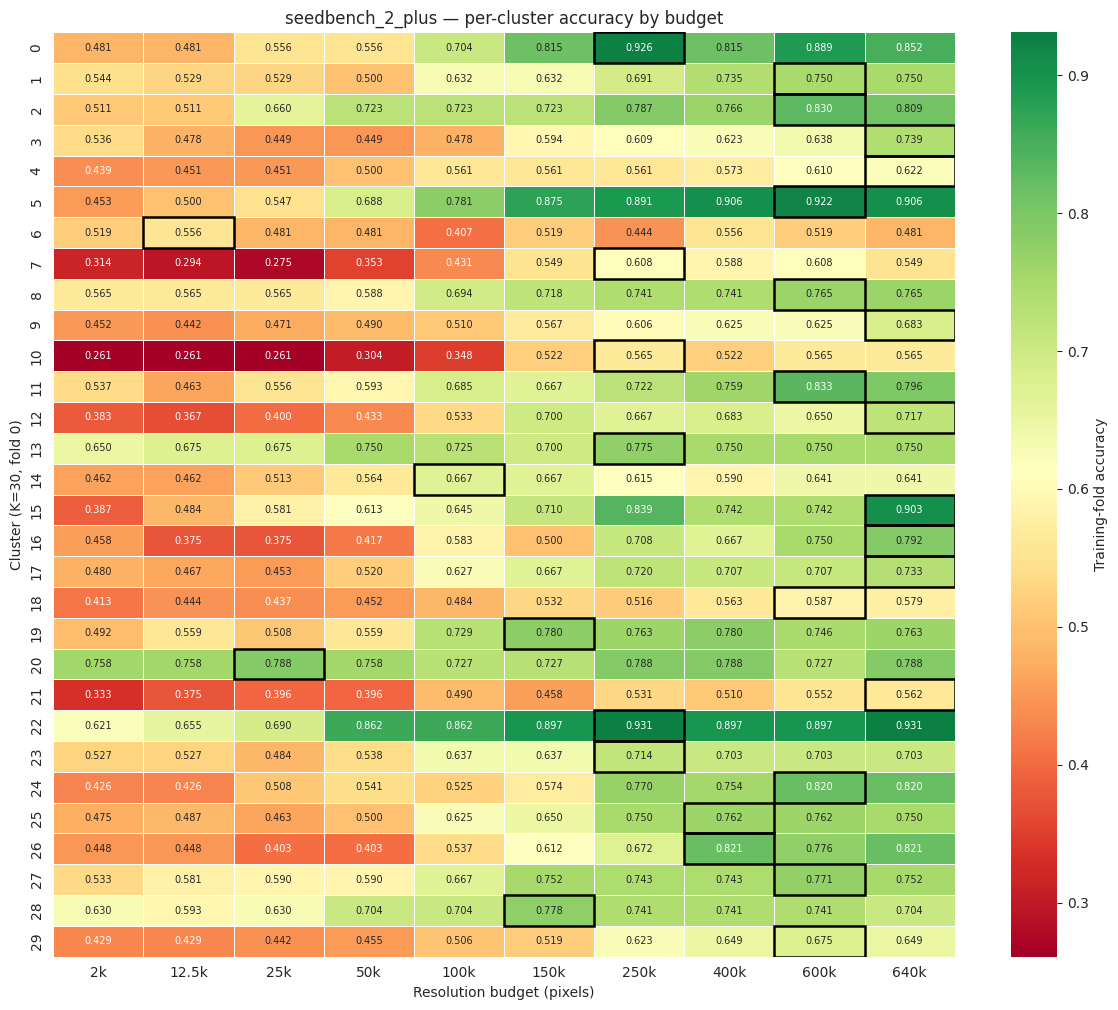

seedbench_2_plus: 8 of 30 clusters peak at the top budget (800,000 px)


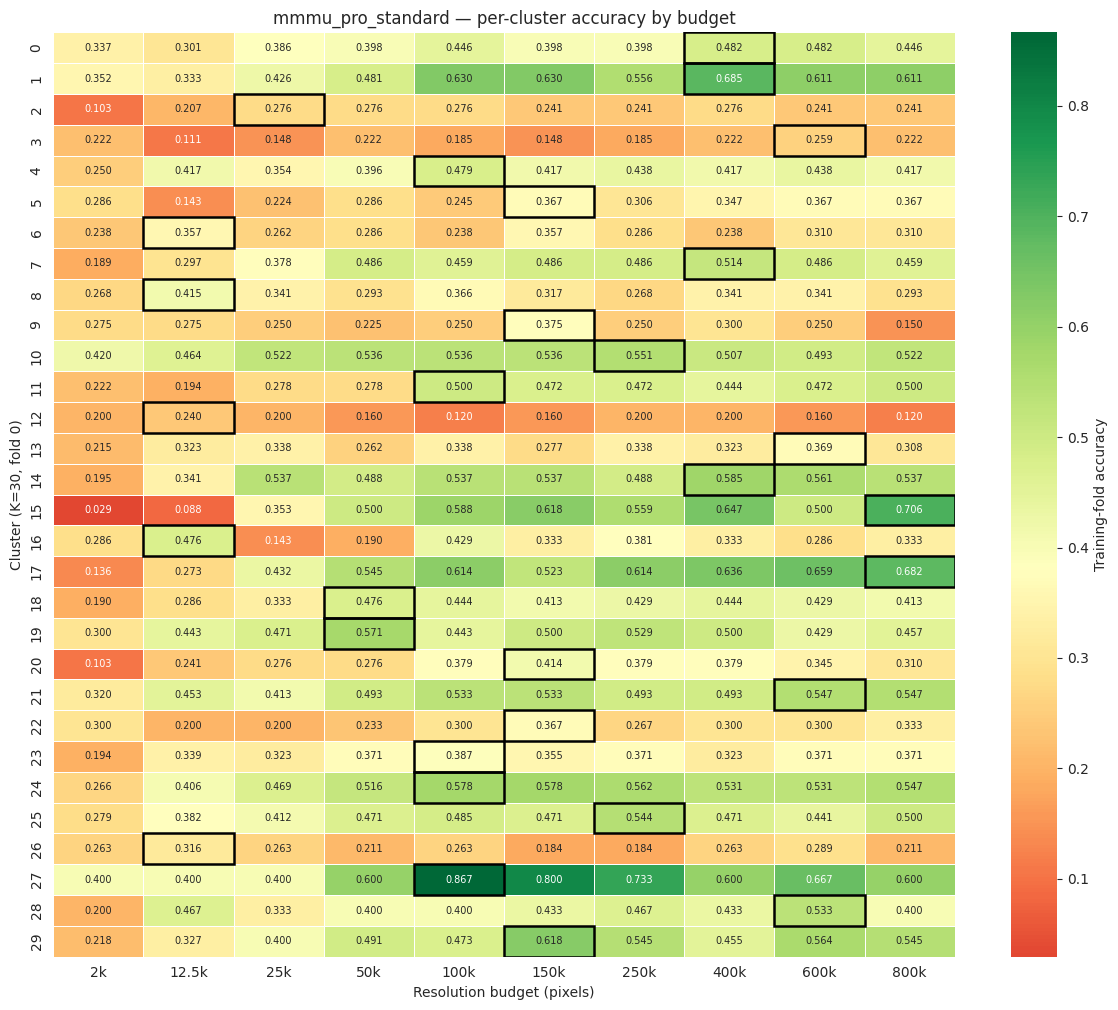

mmmu_pro_standard: 2 of 30 clusters peak at the top budget (800,000 px)


In [7]:
from matplotlib.patches import Rectangle

from clustering.kfold import cluster_accuracy

heatmaps = {}
for label in RUNS:
    table = cluster_accuracy(
        sweeps[label], embeddings[label], SUMMARY_K, HEATMAP_FOLD, N_FOLDS, RANDOM_STATE
    )
    heatmaps[label] = table
    table.to_csv(RESULTS_DIR / f"cluster_accuracy_{label}.csv")

    grid = table.drop(columns="n_questions")
    fig, ax = plt.subplots(figsize=(12, max(6, SUMMARY_K * 0.34)))
    sns.heatmap(grid, annot=True, fmt=".3f", annot_kws={"fontsize": 7}, cmap="RdYlGn",
                center=float(grid.to_numpy().mean()), linewidths=0.5,
                cbar_kws={"label": "Training-fold accuracy"}, ax=ax)
    for row, (_, accuracies) in enumerate(grid.iterrows()):
        ax.add_patch(Rectangle((int(accuracies.to_numpy().argmax()), row), 1, 1,
                               fill=False, edgecolor="black", lw=1.8))
    ax.set_xticklabels([rung(label, b) for b in grid.columns])
    ax.set_xlabel("Resolution budget (pixels)")
    ax.set_ylabel(f"Cluster (K={SUMMARY_K}, fold {HEATMAP_FOLD})")
    ax.set_title(f"{label} — per-cluster accuracy by budget")
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / f"cluster_accuracy_heatmap_{label}.pdf", bbox_inches="tight")
    plt.show()

    peaks = grid.to_numpy().argmax(axis=1)
    top = (peaks == grid.shape[1] - 1).sum()
    print(f"{label}: {top} of {SUMMARY_K} clusters peak at the top budget "
          f"({int(grid.columns[-1]):,} px)")

---
## 5. Strategy comparison at a single K

The paper figure: accuracy against relative cost at `SUMMARY_K`, with error bars
showing the spread across folds on **both** axes. The routed strategies vary in
cost between folds — different clusters get different budgets — which a single
split could not show.

In [8]:
from clustering.kfold import strategy_summary

COLUMNS = ["strategy", "accuracy", "accuracy_sd", "cost_pct", "cost_pct_sd"]

summaries = {label: strategy_summary(folds[label], SUMMARY_K) for label in RUNS}
for label, table in summaries.items():
    table.insert(0, "benchmark", label)
    table.insert(1, "name", [NAMES[s] if s in NAMES else rung(label, int(s.replace("fixed_", "")))
                             for s in table["strategy"]])
    print(f"── {label} ── {N_FOLDS}-fold, K={SUMMARY_K} (mean ± std across folds)")
    print(table[COLUMNS].round(4).to_string(index=False))
    print()

    # A paper-ready rendering of the same rows, so the numbers are never retyped.
    (RESULTS_DIR / f"strategy_comparison_{label}.tex").write_text(
        table[["name", "accuracy", "accuracy_sd", "cost_pct", "cost_pct_sd"]]
        .rename(columns={"name": "Strategy", "accuracy": "Accuracy", "accuracy_sd": "Acc. SD",
                         "cost_pct": "Cost (\\%)", "cost_pct_sd": "Cost SD"})
        .to_latex(index=False, float_format="%.4f", escape=False)
    )

pd.concat(summaries.values(), ignore_index=True).to_csv(RESULTS_DIR / "kfold_strategy_comparison.csv", index=False)

── seedbench_2_plus ── 5-fold, K=30 (mean ± std across folds)
    strategy  accuracy  accuracy_sd  cost_pct  cost_pct_sd
  fixed_2000    0.4704       0.0256    0.3025       0.0000
 fixed_12500    0.4752       0.0239    1.9252       0.0000
 fixed_25000    0.4923       0.0183    3.9006       0.0000
 fixed_50000    0.5279       0.0127    7.7702       0.0000
fixed_100000    0.5951       0.0120   15.6025       0.0000
fixed_150000    0.6342       0.0244   23.4014       0.0000
fixed_250000    0.6794       0.0100   39.0625       0.0000
fixed_400000    0.6935       0.0087   62.4100       0.0000
fixed_600000    0.7062       0.0104   93.6056       0.0000
fixed_800000    0.7123       0.0167  100.0000       0.0000
efficient_95    0.6759       0.0249   53.2586       3.6352
        best    0.6864       0.0140   74.6469       4.0596
efficient_99    0.6864       0.0140   74.6469       4.0596

── mmmu_pro_standard ── 5-fold, K=30 (mean ± std across folds)
    strategy  accuracy  accuracy_sd  cost_pct  c

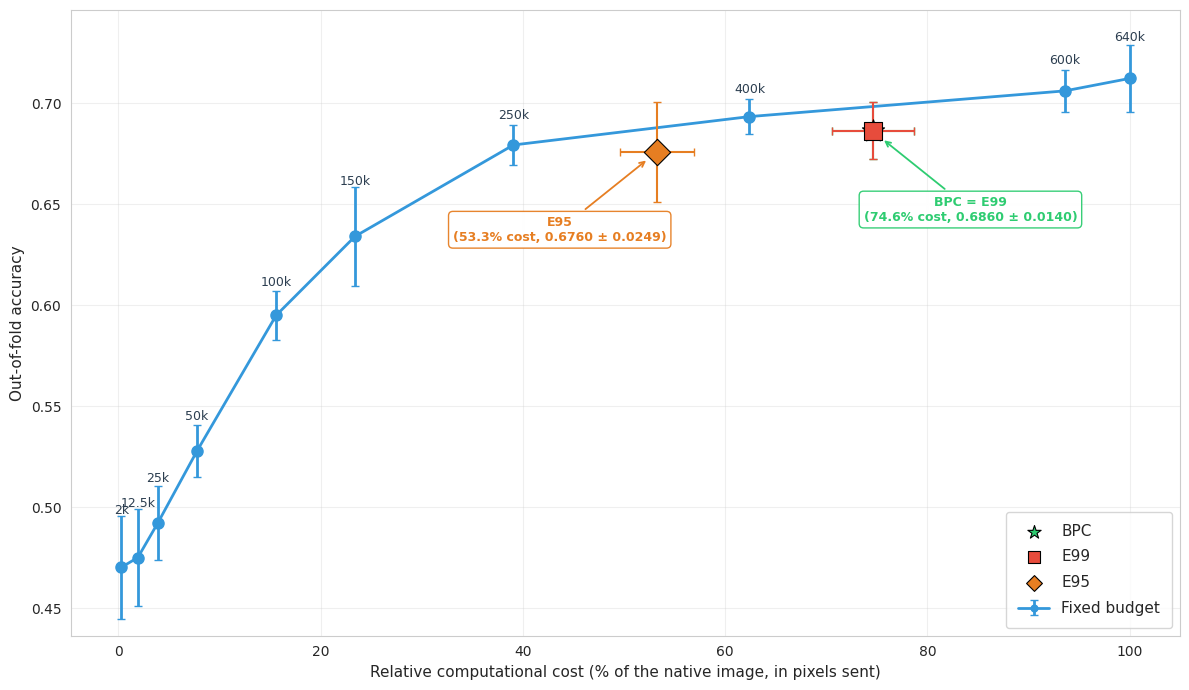

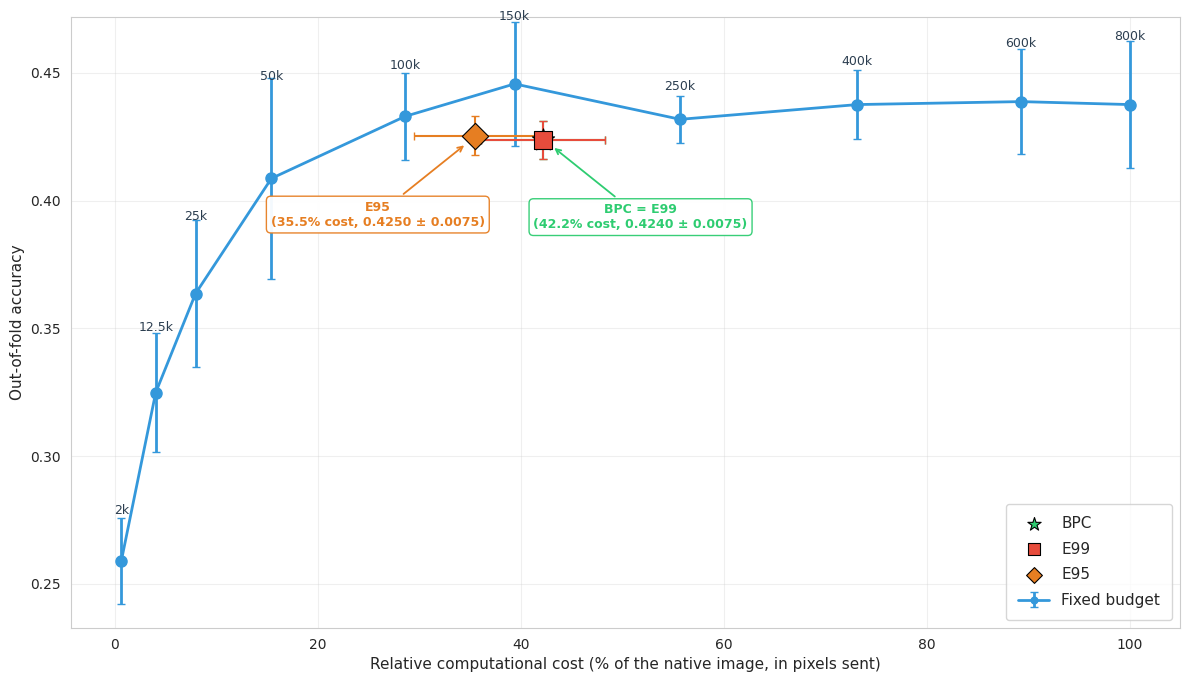

In [9]:
# One frame per distinct point (coincident strategies share a frame), placed
# just below its point; the horizontal split keeps near-coincident points apart
FRAME_OFFSETS = [(-70, -46), (70, -46), (0, -100)]

for label in RUNS:
    table = summaries[label]
    fig, ax = plt.subplots(figsize=(12, 7))

    xs, ys = table["cost_pct"], table["accuracy"]
    x_pad, y_pad = 0.05 * (xs.max() - xs.min()), 0.14 * (ys.max() - ys.min())
    ax.set_xlim(xs.min() - x_pad, xs.max() + x_pad)
    y0, y1 = ys.min() - y_pad, ys.max() + y_pad
    ax.set_ylim(y0, y1)

    fixed = table[table["is_fixed"]]
    ax.errorbar(fixed["cost_pct"], fixed["accuracy"], yerr=fixed["accuracy_sd"],
                fmt="o-", color="#3498db", lw=2, ms=8, capsize=3,
                label="Fixed budget", zorder=3)

    # Labels sit just past the error bar so label and bar never collide
    ax_h_pts = fig.get_size_inches()[1] * 72 * 0.78
    for _, row in fixed.iterrows():
        err_pts = row["accuracy_sd"] / (y1 - y0) * ax_h_pts
        ax.annotate(rung(label, int(row["strategy"].replace("fixed_", ""))),
                    (row["cost_pct"], row["accuracy"]),
                    textcoords="offset points", xytext=(0, 6 + err_pts), ha="center",
                    fontsize=9, color="#2c3e50")

    groups = {}
    for name, (marker, colour, size) in STYLE.items():
        row = table[table["strategy"] == name].iloc[0]
        ax.errorbar(row["cost_pct"], row["accuracy"],
                    xerr=row["cost_pct_sd"], yerr=row["accuracy_sd"],
                    fmt="none", ecolor=colour, capsize=3, zorder=4)
        ax.scatter(row["cost_pct"], row["accuracy"], marker=marker, c=colour, s=size,
                   zorder=5, edgecolors="black", linewidth=0.8, label=NAMES[name])
        key = (round(row["cost_pct"], 3), round(row["accuracy"], 3))
        groups.setdefault(key, ([], row["accuracy_sd"]))[0].append(name)

    # Fewer frames than offsets when strategies coincide, hence strict=False.
    for offset, ((cost, acc), (names, acc_sd)) in zip(FRAME_OFFSETS, sorted(groups.items()), strict=False):
        colour = STYLE[names[0]][1]
        ax.annotate(
            " = ".join(NAMES[n] for n in names) + f"\n({cost:.1f}% cost, {acc:.4f} ± {acc_sd:.4f})",
            xy=(cost, acc), xycoords="data",
            xytext=offset, textcoords="offset points",
            ha="center", va="top", fontsize=9, fontweight="bold", color=colour,
            arrowprops=dict(arrowstyle="->", color=colour, lw=1.3, shrinkB=10),
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=colour, alpha=0.95))

    ax.set_xlabel(f"Relative computational cost (% of the native image, in {COST_LABEL})", fontsize=11)
    ax.set_ylabel("Out-of-fold accuracy", fontsize=11)
    ax.legend(loc="lower right", fontsize=11, markerscale=0.6, labelspacing=0.7, borderpad=0.8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / f"kfold_accuracy_vs_cost_{label}.pdf", bbox_inches="tight")
    plt.show()

---
## 6. Findings

Read the lift column, not the accuracy column. Fill this in from the run:

- is lift positive, and at how many of the K values tested?
- is it larger than the fold-to-fold standard deviation (`accuracy_sd`)?
- does either benchmark behave differently from the other?

A routing policy that only matches the fixed frontier is telling you the useful
signal is *how much resolution the benchmark needs on average*, not *which
question needs what* — in which case the simplest correct action is to pick one
cheaper fixed budget.